# Kapitel 7 – Signifikanztests: Übungsbeispiele

**T4INF2001 Mathematik III – DHBW Stuttgart**

Dieses Notebook enthält Rechenbeispiele zu den wichtigsten Signifikanztests aus Kapitel 7. Alle Beispiele sind so aufgebaut, dass zunächst die Berechnung von Hand nachvollzogen und anschließend mit `scipy.stats` überprüft wird.

> **Hinweis:** Für alle Tests werden nur `numpy`, `matplotlib` und `scipy` verwendet.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (8, 4)

---
## 7.2 Einstichproben-Gaußtest ($\sigma$ bekannt)

**Beispiel: Neue API-Version**

Ein Entwicklerteam behauptet, eine neue API-Version sei schneller als die alte.
- Alte Version: $\mu_0 = 200$ ms
- Bekannt: $\sigma = 30$ ms
- Messung: $n = 50$, $\bar{x} = 185$ ms

**Hypothesen:** $H_0\colon \mu \geq 200$ vs. $H_1\colon \mu < 200$ (linksseitig)

In [2]:
# --- Parameter anpassen ---
mu_0 = 200
sigma = 30
n = 50
x_bar = 185
alpha = 0.05

# Teststatistik
z = (x_bar - mu_0) / (sigma / np.sqrt(n))
print(f"Teststatistik: z = {z:.4f}")

# Kritischer Wert (linksseitig)
z_krit = -stats.norm.ppf(1 - alpha)
print(f"Kritischer Wert: -z_{{1-α}} = {z_krit:.4f}")

# p-Wert
p_wert = stats.norm.cdf(z)
print(f"p-Wert: {p_wert:.6f}")

# Entscheidung
if z < z_krit:
    print(f"\nEntscheidung: z = {z:.2f} < {z_krit:.3f} → H₀ ablehnen")
    print("Die neue API-Version ist signifikant schneller.")
else:
    print(f"\nEntscheidung: z = {z:.2f} ≥ {z_krit:.3f} → H₀ nicht ablehnen")

Teststatistik: z = -3.5355
Kritischer Wert: -z_{1-α} = -1.6449
p-Wert: 0.000203

Entscheidung: z = -3.54 < -1.645 → H₀ ablehnen
Die neue API-Version ist signifikant schneller.


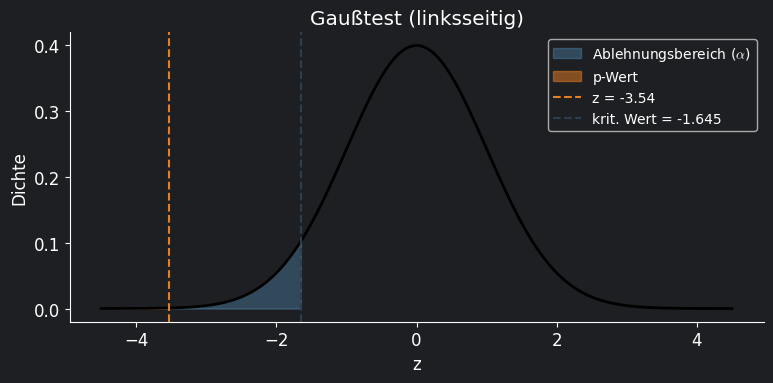

In [3]:
# Visualisierung
x = np.linspace(-4.5, 4.5, 500)
y = stats.norm.pdf(x)

fig, ax = plt.subplots()
ax.plot(x, y, 'k-', lw=2)
ax.fill_between(x[x <= z_krit], stats.norm.pdf(x[x <= z_krit]), alpha=0.3, color='#5dade2', label=r'Ablehnungsbereich ($\alpha$)')
ax.fill_between(x[x <= z], stats.norm.pdf(x[x <= z]), alpha=0.5, color='#e67e22', label='p-Wert')
ax.axvline(z, color='#e67e22', ls='--', lw=1.5, label=f'z = {z:.2f}')
ax.axvline(z_krit, color='#2c3e50', ls='--', lw=1.5, label=f'krit. Wert = {z_krit:.3f}')
ax.set_xlabel('z')
ax.set_ylabel('Dichte')
ax.set_title('Gaußtest (linksseitig)')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7.5 Binomialtest

**IT-Beispiel: Fehlerrate nach Bugfix**

Vor dem Bugfix: Fehlerrate $p_0 = 0{,}05$. Nach dem Fix: $n = 200$ Requests, $k = 6$ Fehler.

**Hypothesen:** $H_0\colon p = 0{,}05$ vs. $H_1\colon p < 0{,}05$ (linksseitig)

In [4]:
# --- Parameter anpassen ---
p_0 = 0.05
n = 200
k = 6
alpha = 0.05

# Exakter p-Wert (Binomialverteilung)
p_exakt = stats.binom.cdf(k, n, p_0)
print(f"Exakter p-Wert: P(X ≤ {k} | p = {p_0}) = {p_exakt:.4f}")
print(f"Erwartung unter H₀: E(X) = n·p₀ = {n*p_0:.0f}")

# Normalapproximation
p_hat = k / n
z = (p_hat - p_0) / np.sqrt(p_0 * (1 - p_0) / n)
p_approx = stats.norm.cdf(z)
print(f"\nNormalapproximation: z = {z:.4f}")
print(f"p-Wert (approx.): {p_approx:.4f}")

# Mit Stetigkeitskorrektur
z_korr = ((k + 0.5) / n - p_0) / np.sqrt(p_0 * (1 - p_0) / n)
p_korr = stats.norm.cdf(z_korr)
print(f"Mit Stetigkeitskorrektur: z = {z_korr:.4f}, p = {p_korr:.4f}")

# Entscheidung
print(f"\nEntscheidung: p = {p_exakt:.4f} > {alpha} → H₀ nicht ablehnen")
print("Keine ausreichenden Hinweise für eine Verbesserung.")

Exakter p-Wert: P(X ≤ 6 | p = 0.05) = 0.1237
Erwartung unter H₀: E(X) = n·p₀ = 10

Normalapproximation: z = -1.2978
p-Wert (approx.): 0.0972
Mit Stetigkeitskorrektur: z = -1.1355, p = 0.1281

Entscheidung: p = 0.1237 > 0.05 → H₀ nicht ablehnen
Keine ausreichenden Hinweise für eine Verbesserung.


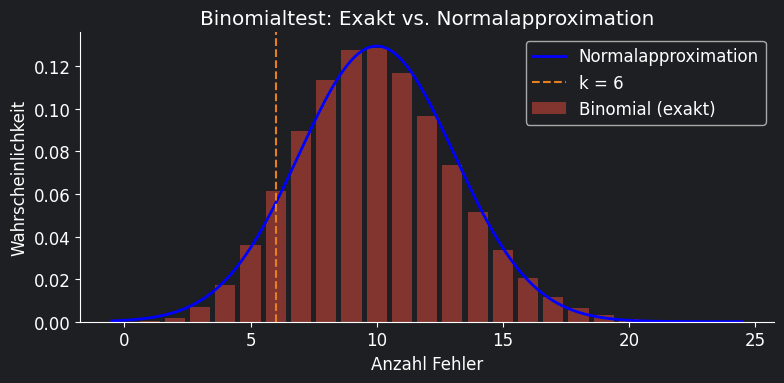

In [5]:
# Vergleich: Exakte vs. Normalapproximation
x_vals = np.arange(0, 25)
fig, ax = plt.subplots()
ax.bar(x_vals, stats.binom.pmf(x_vals, n, p_0), color='#e74c3c', alpha=0.5, label='Binomial (exakt)')
x_cont = np.linspace(-0.5, 24.5, 300)
ax.plot(x_cont, stats.norm.pdf(x_cont, n*p_0, np.sqrt(n*p_0*(1-p_0))), 'b-', lw=2, label='Normalapproximation')
ax.axvline(k, color='#e67e22', ls='--', lw=1.5, label=f'k = {k}')
ax.set_xlabel('Anzahl Fehler')
ax.set_ylabel('Wahrscheinlichkeit')
ax.set_title('Binomialtest: Exakt vs. Normalapproximation')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7.6 Einstichproben-t-Test und approximativer Gaußtest

**IT-Beispiel: SLA-Einhaltung**

Ein SLA garantiert eine mittlere Response-Zeit von maximal 150 ms.
- Messung: $n = 25$, $\bar{x} = 158$ ms, $s = 20$ ms

**Hypothesen:** $H_0\colon \mu \leq 150$ vs. $H_1\colon \mu > 150$ (rechtsseitig)

In [6]:
# --- Parameter anpassen ---
mu_0 = 150
n = 25
x_bar = 158
s = 20
alpha = 0.05

# Teststatistik
t = (x_bar - mu_0) / (s / np.sqrt(n))
print(f"Teststatistik: t = {t:.4f}")

# Kritischer Wert (rechtsseitig)
t_krit = stats.t.ppf(1 - alpha, df=n-1)
print(f"Kritischer Wert: t_{{24; 0,95}} = {t_krit:.3f}")

# p-Wert
p_wert = 1 - stats.t.cdf(t, df=n-1)
print(f"p-Wert: {p_wert:.4f}")

if t > t_krit:
    print(f"\nEntscheidung: t = {t:.2f} > {t_krit:.3f} → H₀ ablehnen")
    print("Die mittlere Response-Zeit liegt signifikant über dem SLA-Wert.")
else:
    print(f"\nEntscheidung: t = {t:.2f} ≤ {t_krit:.3f} → H₀ nicht ablehnen")


Teststatistik: t = 2.0000
Kritischer Wert: t_{24; 0,95} = 1.711
p-Wert: 0.0285

Entscheidung: t = 2.00 > 1.711 → H₀ ablehnen
Die mittlere Response-Zeit liegt signifikant über dem SLA-Wert.


---
## 7.7 Differenztests

### 7.7.1 Gepaarter t-Test

**IT-Beispiel: Load-Balancer-Vergleich**

Zwei Load-Balancer werden auf denselben 15 Servern getestet:

In [7]:
# --- Parameter anpassen ---
np.random.seed(123)
lb_A = np.array([120, 135, 142, 118, 155, 130, 148, 125, 160, 138, 122, 145, 133, 150, 128])
lb_B = lb_A - np.random.normal(5, 3, 15)  # B ist im Schnitt 5ms schneller

D = lb_A - lb_B
d_bar = D.mean()
s_D = D.std(ddof=1)
n = len(D)

print(f"Differenzen D_i = A - B:")
print(f"  D̄ = {d_bar:.2f}")
print(f"  s_D = {s_D:.2f}")
print(f"  n = {n}")

# Teststatistik
t = d_bar / (s_D / np.sqrt(n))
df = n - 1
p_wert = 2 * (1 - stats.t.cdf(abs(t), df=df))
print(f"\nTeststatistik: t = {t:.4f}")
print(f"p-Wert (zweiseitig): {p_wert:.4f}")

# Vergleich mit scipy
t_scipy, p_scipy = stats.ttest_rel(lb_A, lb_B)
print(f"\nscipy.stats.ttest_rel: t = {t_scipy:.4f}, p = {p_scipy:.4f}")

if p_wert < 0.05:
    print("\n→ H₀ ablehnen: Die Load-Balancer unterscheiden sich signifikant.")
else:
    print("\n→ H₀ nicht ablehnen.")

Differenzen D_i = A - B:
  D̄ = 4.39
  s_D = 3.47
  n = 15

Teststatistik: t = 4.9033
p-Wert (zweiseitig): 0.0002

scipy.stats.ttest_rel: t = 4.9033, p = 0.0002

→ H₀ ablehnen: Die Load-Balancer unterscheiden sich signifikant.


---
## 7.8 $\chi^2$-Test für die Varianz

**IT-Beispiel: Netzwerklatenz**

Ein Service garantiert $\sigma \leq 15$ ms. Messung: $n = 20$, $s = 18$ ms.

**Hypothesen:** $H_0\colon \sigma \leq 15$ vs. $H_1\colon \sigma > 15$ (rechtsseitig)

In [8]:
# --- Parameter anpassen ---
sigma_0 = 15
n = 20
s = 18
alpha = 0.05

# Teststatistik
chi2 = (n - 1) * s**2 / sigma_0**2
df = n - 1
print(f"Teststatistik: χ² = {chi2:.2f}")

# Kritischer Wert
chi2_krit = stats.chi2.ppf(1 - alpha, df=df)
print(f"Kritischer Wert: χ²_{{19; 0,95}} = {chi2_krit:.2f}")

# p-Wert
p_wert = 1 - stats.chi2.cdf(chi2, df=df)
print(f"p-Wert: {p_wert:.4f}")

if chi2 > chi2_krit:
    print(f"\nEntscheidung: χ² = {chi2:.2f} > {chi2_krit:.2f} → H₀ ablehnen")
else:
    print(f"\nEntscheidung: χ² = {chi2:.2f} < {chi2_krit:.2f} → H₀ nicht ablehnen")

Teststatistik: χ² = 27.36
Kritischer Wert: χ²_{19; 0,95} = 30.14
p-Wert: 0.0965

Entscheidung: χ² = 27.36 < 30.14 → H₀ nicht ablehnen


---
## 7.9 Zweistichprobentests

### 7.9.1 Zweistichproben-t-Test (gleiche Varianz)

Zwei Server werden verglichen. Sind die mittleren Antwortzeiten verschieden?

In [9]:
# --- Parameter anpassen ---
np.random.seed(42)
server_A = np.random.normal(150, 20, 30)
server_B = np.random.normal(160, 22, 35)

x_bar_A, x_bar_B = server_A.mean(), server_B.mean()
s_A, s_B = server_A.std(ddof=1), server_B.std(ddof=1)
n_A, n_B = len(server_A), len(server_B)

print(f"Server A: n = {n_A}, x̄ = {x_bar_A:.2f}, s = {s_A:.2f}")
print(f"Server B: n = {n_B}, x̄ = {x_bar_B:.2f}, s = {s_B:.2f}")

# Varianzhomogenität prüfen
ratio = max(s_A**2, s_B**2) / min(s_A**2, s_B**2)
print(f"\nVarianzverhältnis: s²_max / s²_min = {ratio:.2f}", end="")
print(f" → {'< 3 ✓ (homogen)' if ratio < 3 else '≥ 3 ✗ (Welch-Test!)'}")

# Gepoolte Varianz
s_p = np.sqrt(((n_A-1)*s_A**2 + (n_B-1)*s_B**2) / (n_A + n_B - 2))
print(f"Gepoolte Standardabweichung: s_p = {s_p:.2f}")

# Teststatistik
t = (x_bar_A - x_bar_B) / (s_p * np.sqrt(1/n_A + 1/n_B))
df = n_A + n_B - 2
print(f"Teststatistik: t = {t:.4f}, df = {df}")

# p-Wert (zweiseitig)
p_wert = 2 * stats.t.cdf(-abs(t), df=df)
print(f"p-Wert: {p_wert:.4f}")

# Vergleich mit scipy
t_scipy, p_scipy = stats.ttest_ind(server_A, server_B, equal_var=True)
print(f"\nscipy.stats.ttest_ind: t = {t_scipy:.4f}, p = {p_scipy:.4f}")

Server A: n = 30, x̄ = 146.24, s = 18.00
Server B: n = 35, x̄ = 156.36, s = 20.04

Varianzverhältnis: s²_max / s²_min = 1.24 → < 3 ✓ (homogen)
Gepoolte Standardabweichung: s_p = 19.13
Teststatistik: t = -2.1274, df = 63
p-Wert: 0.0373

scipy.stats.ttest_ind: t = -2.1274, p = 0.0373


### 7.9.3 Welch-Test (ungleiche Varianzen)

Gleiche Daten, aber ohne Annahme gleicher Varianzen:

In [10]:
# Welch-Test
t_welch, p_welch = stats.ttest_ind(server_A, server_B, equal_var=False)
print(f"Welch-Test: t = {t_welch:.4f}, p = {p_welch:.4f}")

# Welch-Satterthwaite Freiheitsgrade von Hand
nu_num = (s_A**2/n_A + s_B**2/n_B)**2
nu_den = (s_A**2/n_A)**2/(n_A-1) + (s_B**2/n_B)**2/(n_B-1)
nu = nu_num / nu_den
print(f"Welch-Satterthwaite df: ν = {nu:.1f}")

Welch-Test: t = -2.1452, p = 0.0358
Welch-Satterthwaite df: ν = 62.8


---
## 7.9.4 Vergleich zweier Anteilswerte (A/B-Test)

**IT-Beispiel: Button-Klickrate**

- Variante A: $n_A = 1000$, $k_A = 120$ Klicks → $\hat{p}_A = 0{,}12$
- Variante B: $n_B = 1000$, $k_B = 145$ Klicks → $\hat{p}_B = 0{,}145$

**Hypothesen:** $H_0\colon p_A = p_B$ vs. $H_1\colon p_A \neq p_B$ (zweiseitig)

In [11]:
# --- Parameter anpassen ---
n_A, k_A = 1000, 120
n_B, k_B = 1000, 145
alpha = 0.05

p_A = k_A / n_A
p_B = k_B / n_B
p_pool = (k_A + k_B) / (n_A + n_B)

print(f"p̂_A = {p_A:.3f}, p̂_B = {p_B:.3f}")
print(f"Gepoolter Schätzer: p̂ = {p_pool:.4f}")

# Teststatistik
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
z = (p_A - p_B) / se
print(f"Teststatistik: z = {z:.4f}")

# p-Wert (zweiseitig)
p_wert = 2 * stats.norm.cdf(-abs(z))
print(f"p-Wert: {p_wert:.4f}")

# Kritischer Wert
z_krit = stats.norm.ppf(1 - alpha/2)
print(f"Kritischer Wert: z_{{0,975}} = {z_krit:.3f}")

if abs(z) > z_krit:
    print(f"\nEntscheidung: |z| = {abs(z):.2f} > {z_krit:.3f} → H₀ ablehnen")
else:
    print(f"\nEntscheidung: |z| = {abs(z):.2f} < {z_krit:.3f} → H₀ nicht ablehnen")
    print("Die Klickraten unterscheiden sich nicht signifikant.")

p̂_A = 0.120, p̂_B = 0.145
Gepoolter Schätzer: p̂ = 0.1325
Teststatistik: z = -1.6489
p-Wert: 0.0992
Kritischer Wert: z_{0,975} = 1.960

Entscheidung: |z| = 1.65 < 1.960 → H₀ nicht ablehnen
Die Klickraten unterscheiden sich nicht signifikant.


---
## 7.10 $\chi^2$-Anpassungstest

**IT-Beispiel: Gleichverteilung von Fehlern**

Ein System soll Fehler gleichmäßig über Wochentage verteilen. Beobachtung: 350 Fehler.

In [12]:
# --- Parameter anpassen ---
beobachtet = np.array([55, 48, 52, 50, 47, 51, 47])
tage = ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So']
n_total = beobachtet.sum()
erwartet = np.full(7, n_total / 7)  # Gleichverteilung

print(f"Beobachtet: {dict(zip(tage, beobachtet))}")
print(f"Erwartet:   {erwartet[0]:.1f} pro Tag")

# Teststatistik
chi2 = np.sum((beobachtet - erwartet)**2 / erwartet)
df = len(beobachtet) - 1  # k-1, keine Parameter geschätzt
print(f"\nTeststatistik: χ² = {chi2:.2f}")
print(f"Freiheitsgrade: k - 1 = {df}")

# Kritischer Wert
chi2_krit = stats.chi2.ppf(0.95, df=df)
print(f"Kritischer Wert: χ²_{{6; 0,95}} = {chi2_krit:.2f}")

# p-Wert
p_wert = 1 - stats.chi2.cdf(chi2, df=df)
print(f"p-Wert: {p_wert:.4f}")

# scipy Vergleich
chi2_scipy, p_scipy = stats.chisquare(beobachtet, f_exp=erwartet)
print(f"\nscipy.stats.chisquare: χ² = {chi2_scipy:.2f}, p = {p_scipy:.4f}")

print(f"\nEntscheidung: χ² = {chi2:.2f} < {chi2_krit:.2f} → H₀ nicht ablehnen")
print("Die Fehler sind gleichmäßig verteilt.")

Beobachtet: {'Mo': np.int64(55), 'Di': np.int64(48), 'Mi': np.int64(52), 'Do': np.int64(50), 'Fr': np.int64(47), 'Sa': np.int64(51), 'So': np.int64(47)}
Erwartet:   50.0 pro Tag

Teststatistik: χ² = 1.04
Freiheitsgrade: k - 1 = 6
Kritischer Wert: χ²_{6; 0,95} = 12.59
p-Wert: 0.9841

scipy.stats.chisquare: χ² = 1.04, p = 0.9841

Entscheidung: χ² = 1.04 < 12.59 → H₀ nicht ablehnen
Die Fehler sind gleichmäßig verteilt.


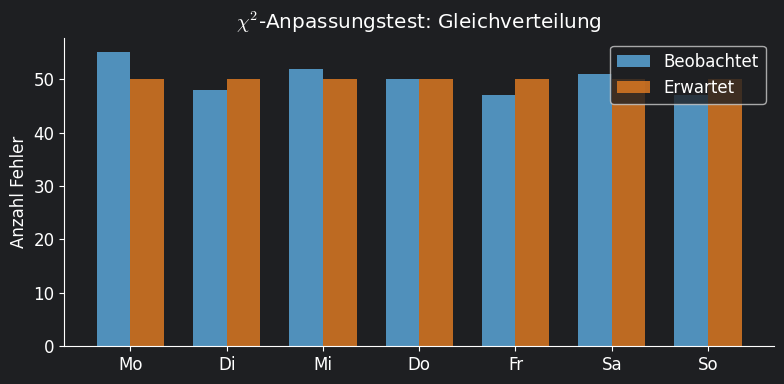

In [13]:
# Visualisierung
fig, ax = plt.subplots()
x_pos = np.arange(7)
width = 0.35
ax.bar(x_pos - width/2, beobachtet, width, label='Beobachtet', color='#5dade2', alpha=0.8)
ax.bar(x_pos + width/2, erwartet, width, label='Erwartet', color='#e67e22', alpha=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(tage)
ax.set_ylabel('Anzahl Fehler')
ax.set_title(r'$\chi^2$-Anpassungstest: Gleichverteilung')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7.11 Kontingenztest ($\chi^2$-Unabhängigkeitstest)

**IT-Beispiel: Betriebssystem und Browser**

Gibt es einen Zusammenhang zwischen Betriebssystem und Browser?

In [14]:
# --- Parameter anpassen ---
beobachtet = np.array([
    [120, 80, 20],   # Windows
    [60,  40, 80],   # macOS
    [40,  50, 10],   # Linux
])
zeilen = ['Windows', 'macOS', 'Linux']
spalten = ['Chrome', 'Firefox', 'Safari']

print("Beobachtete Häufigkeiten:")
for i, z in enumerate(zeilen):
    print(f"  {z:8s}: {beobachtet[i]}")

# Erwartete Häufigkeiten
n = beobachtet.sum()
zeilen_summe = beobachtet.sum(axis=1)
spalten_summe = beobachtet.sum(axis=0)
erwartet = np.outer(zeilen_summe, spalten_summe) / n

print(f"\nErwartete Häufigkeiten:")
for i, z in enumerate(zeilen):
    print(f"  {z:8s}: [{erwartet[i,0]:.1f}, {erwartet[i,1]:.1f}, {erwartet[i,2]:.1f}]")

# Teststatistik
chi2 = np.sum((beobachtet - erwartet)**2 / erwartet)
df = (len(zeilen) - 1) * (len(spalten) - 1)
print(f"\nTeststatistik: χ² = {chi2:.2f}")
print(f"Freiheitsgrade: (r-1)(c-1) = {df}")

# p-Wert
p_wert = 1 - stats.chi2.cdf(chi2, df=df)
chi2_krit = stats.chi2.ppf(0.95, df=df)
print(f"Kritischer Wert: χ²_{{4; 0,95}} = {chi2_krit:.2f}")
print(f"p-Wert: {p_wert:.6f}")

# scipy Vergleich
chi2_scipy, p_scipy, dof, expected = stats.chi2_contingency(beobachtet, correction=False)
print(f"\nscipy.stats.chi2_contingency: χ² = {chi2_scipy:.2f}, p = {p_scipy:.6f}")

print(f"\nEntscheidung: {chi2:.2f} > {chi2_krit:.2f} → H₀ ablehnen (hochsignifikant)")
print("Es besteht ein Zusammenhang zwischen Betriebssystem und Browser-Wahl.")

Beobachtete Häufigkeiten:
  Windows : [120  80  20]
  macOS   : [60 40 80]
  Linux   : [40 50 10]

Erwartete Häufigkeiten:
  Windows : [96.8, 74.8, 48.4]
  macOS   : [79.2, 61.2, 39.6]
  Linux   : [44.0, 34.0, 22.0]

Teststatistik: χ² = 90.24
Freiheitsgrade: (r-1)(c-1) = 4
Kritischer Wert: χ²_{4; 0,95} = 9.49
p-Wert: 0.000000

scipy.stats.chi2_contingency: χ² = 90.24, p = 0.000000

Entscheidung: 90.24 > 9.49 → H₀ ablehnen (hochsignifikant)
Es besteht ein Zusammenhang zwischen Betriebssystem und Browser-Wahl.


---
## 7.12 Korrelationstest

**IT-Beispiel: CPU-Auslastung und Response-Zeit**

$n = 20$, $r = 0{,}62$

**Hypothesen:** $H_0\colon \rho = 0$ vs. $H_1\colon \rho \neq 0$ (zweiseitig)

In [15]:
# --- Parameter anpassen ---
r = 0.62
n = 20
alpha = 0.05

# Teststatistik
t = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
df = n - 2
print(f"Teststatistik: t = {t:.4f}")

# Kritischer Wert (zweiseitig)
t_krit = stats.t.ppf(1 - alpha/2, df=df)
print(f"Kritischer Wert: t_{{18; 0,975}} = {t_krit:.3f}")

# p-Wert
p_wert = 2 * (1 - stats.t.cdf(abs(t), df=df))
print(f"p-Wert: {p_wert:.4f}")

if abs(t) > t_krit:
    print(f"\nEntscheidung: t = {t:.2f} > {t_krit:.3f} → H₀ ablehnen")
    print(f"Signifikant positive Korrelation (r = {r}).")
else:
    print(f"\nEntscheidung: |t| = {abs(t):.2f} ≤ {t_krit:.3f} → H₀ nicht ablehnen")

Teststatistik: t = 3.3526
Kritischer Wert: t_{18; 0,975} = 2.101
p-Wert: 0.0035

Entscheidung: t = 3.35 > 2.101 → H₀ ablehnen
Signifikant positive Korrelation (r = 0.62).


Simulierte Daten: r = 0.739, p = 0.0002


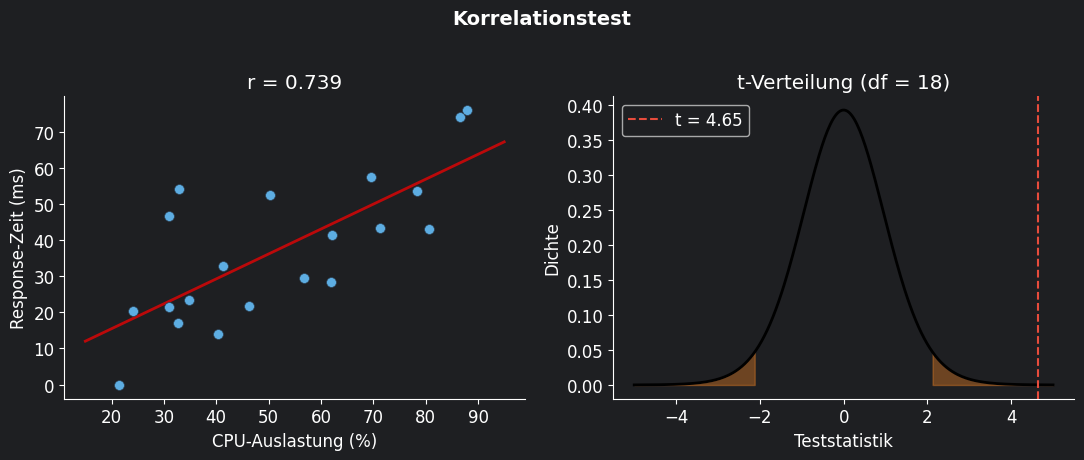

In [16]:
# Simulation mit Daten für die Visualisierung
np.random.seed(42)
x = np.random.uniform(20, 90, n)
y = 0.8 * x + np.random.normal(0, 15, n)

r_sim, p_sim = stats.pearsonr(x, y)
print(f"Simulierte Daten: r = {r_sim:.3f}, p = {p_sim:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Streudiagramm
ax1.scatter(x, y, c='#5dade2', s=50, edgecolors='#2c3e50', lw=0.5, zorder=5)
z_fit = np.polyfit(x, y, 1)
x_line = np.linspace(15, 95, 100)
ax1.plot(x_line, np.poly1d(z_fit)(x_line), 'r-', lw=2, alpha=0.7)
ax1.set_xlabel('CPU-Auslastung (%)')
ax1.set_ylabel('Response-Zeit (ms)')
ax1.set_title(f'r = {r_sim:.3f}')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# t-Verteilung
x_t = np.linspace(-5, 5, 300)
ax2.plot(x_t, stats.t.pdf(x_t, df=n-2), 'k-', lw=2)
t_val = r_sim * np.sqrt(n-2) / np.sqrt(1 - r_sim**2)
t_c = stats.t.ppf(0.975, df=n-2)
ax2.fill_between(x_t[x_t <= -t_c], stats.t.pdf(x_t[x_t <= -t_c], df=n-2), alpha=0.4, color='#e67e22')
ax2.fill_between(x_t[x_t >= t_c], stats.t.pdf(x_t[x_t >= t_c], df=n-2), alpha=0.4, color='#e67e22')
ax2.axvline(t_val, color='#e74c3c', ls='--', lw=1.5, label=f't = {t_val:.2f}')
ax2.set_xlabel('Teststatistik')
ax2.set_ylabel('Dichte')
ax2.set_title(f't-Verteilung (df = {n-2})')
ax2.legend()
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('Korrelationstest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Zusammenfassung: Welchen Test wähle ich?

| Frage | Test | Teststatistik |
|-------|------|---------------|
| $\mu$ testen, $\sigma$ bekannt | Gaußtest | $Z = \frac{\bar{X}-\mu_0}{\sigma/\sqrt{n}}$ |
| $\mu$ testen, $\sigma$ unbekannt | t-Test | $T = \frac{\bar{X}-\mu_0}{S/\sqrt{n}}$ |
| Anteilswert $p$ testen | Binomialtest | exakt oder $z$-Approximation |
| Zwei Anteile vergleichen | A/B-Test | $Z = \frac{\hat{p}_A-\hat{p}_B}{\mathrm{SE}}$ |
| Zwei $\mu$, gleiche $\sigma^2$ | Zweistichproben-t | $T = \frac{\bar{X}-\bar{Y}}{S_p\sqrt{1/n+1/m}}$ |
| Zwei $\mu$, ungleiche $\sigma^2$ | Welch-Test | $T = \frac{\bar{X}-\bar{Y}}{\sqrt{S_X^2/n+S_Y^2/m}}$ |
| Paardifferenzen | Gepaarter t-Test | $T = \frac{\bar{D}}{S_D/\sqrt{n}}$ |
| Varianz $\sigma^2$ testen | $\chi^2$-Varianztest | $\chi^2 = \frac{(n-1)S^2}{\sigma_0^2}$ |
| Verteilung testen | $\chi^2$-Anpassungstest | $\chi^2 = \sum \frac{(n_i-e_i)^2}{e_i}$ |
| Unabhängigkeit | Kontingenztest | $\chi^2 = \sum\sum \frac{(n_{ij}-e_{ij})^2}{e_{ij}}$ |
| Korrelation $\rho$ testen | Korrelationstest | $T = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}$ |